## Import necessary library

In [35]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader

## Get File path and load the csv data

In [36]:
from util.data_path import cassava_price_avg as data_file
from util.data_path import Transformer_for, Transformer_err, weights_path


In [37]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [38]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [39]:
SEQ_LEN = CFG["data"]["seq_len"]
PRED_LEN = CFG["data"]["pred_len"]


# Transformer Model And Predict Graph

## Training the Transformer Model

In [40]:
from util.transformer_model import TransformerRegressor
from util.seq_dataset import SeqDataset
from util.config import CFG
from util.data_path import weights_path


In [41]:
torch.manual_seed(CFG["random_seed"])
np.random.seed(CFG["random_seed"])

series_scaled = train["scaled"].values.astype(np.float32)

ds = SeqDataset(series_scaled, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

model_tf = TransformerRegressor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_tf.parameters(), lr=CFG["transformer"]["learning_rate"])


In [42]:
weights_path.mkdir(parents=True, exist_ok=True)
weight_file = weights_path / f"transformer_{data_file.parent.name}.pth"

if weight_file.exists():
    model_tf.load_state_dict(torch.load(weight_file, weights_only=True))
    print(f"Loaded weights from {weight_file.name}")
else:
    EPOCHS = CFG["transformer"]["epochs"]
    for epoch in range(1, EPOCHS + 1):
        for xb, yb in loader:
            optimizer.zero_grad()
            y_pred = model_tf(xb)
            loss = criterion(y_pred, yb)
            loss.backward()
            optimizer.step()
        if epoch % 50 == 0:
            print(f"Epoch {epoch:3d}/{EPOCHS}  loss = {loss.item():.6f}")
    torch.save(model_tf.state_dict(), weight_file)
    print(f"Saved weights to {weight_file.name}")


Epoch  50/500 — loss = 0.030577
Epoch 100/500 — loss = 0.022652
Epoch 150/500 — loss = 0.019105
Epoch 200/500 — loss = 0.015271
Epoch 250/500 — loss = 0.011840
Epoch 300/500 — loss = 0.010402
Epoch 350/500 — loss = 0.008774
Epoch 400/500 — loss = 0.007460
Epoch 450/500 — loss = 0.006804
Epoch 500/500 — loss = 0.006143


## Predict the data for the next year

In [43]:
model_tf.eval()
with torch.no_grad():
    window = (
        torch.tensor(series_scaled[-SEQ_LEN:], dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(-1)
    )
    tf_forecast_scaled = model_tf(window).squeeze(0).numpy()
    tf_forecast = scaler.inverse_transform(tf_forecast_scaled.reshape(-1, 1)).flatten()

tf_forecast = pd.Series(
    tf_forecast,
    index=pd.date_range("2024-01-01", periods=12, freq="MS"),
    name="TF_forecast",
)

In [44]:
cmp = pd.concat([future["price"], tf_forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            price  TF_forecast
2024-01-01   3.65         3.43
2024-02-01   3.65         3.01
2024-03-01   3.57         2.93
2024-04-01   3.24         2.79
2024-05-01   3.19         2.50
2024-06-01   3.09         2.61
2024-07-01   3.06         2.71
2024-08-01   2.95         2.90
2024-09-01   2.86         2.92
2024-10-01   2.65         2.57
2024-11-01   2.60         2.63
2024-12-01   2.32         2.31


## Compare The Error of a predicted data in a table format

In [45]:
error = cmp["price"] - cmp["TF_forecast"]
abs_error = error.abs()

# Guard against division by zero for percentage error
denom = cmp["price"].replace(0, np.nan)
abs_pct_error = (abs_error / denom) * 100

# Metrics
mae_tf = mean_absolute_error(cmp["price"], cmp["TF_forecast"])
mape_tf = abs_pct_error.mean()  # Mean Absolute Percentage Error

print("\n--- Monthly Errors (Transformer) ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["price"],
        "forecast": cmp["TF_forecast"],
        "error": error,
        "abs_error": abs_error,
        "abs_pct_error": abs_pct_error,
    }
)
print(error_df.round(4))

print(f"\nTransformer MAE (2024): {mae_tf:.6f}")
print(f"Transformer MAPE (2024): {mape_tf:.4f}%")
print(f"Transformer Accuracy = {100 - (mae_tf / cmp['price'].mean() * 100):.2f}%")
# ...existing code...


--- Monthly Errors (Transformer) ---
            actual  forecast   error  abs_error  abs_pct_error
2024-01-01    3.65    3.4335  0.2165     0.2165         5.9324
2024-02-01    3.65    3.0122  0.6378     0.6378        17.4753
2024-03-01    3.57    2.9296  0.6404     0.6404        17.9397
2024-04-01    3.24    2.7880  0.4520     0.4520        13.9510
2024-05-01    3.19    2.4963  0.6937     0.6937        21.7472
2024-06-01    3.09    2.6134  0.4766     0.4766        15.4256
2024-07-01    3.06    2.7129  0.3471     0.3471        11.3447
2024-08-01    2.95    2.9007  0.0493     0.0493         1.6716
2024-09-01    2.86    2.9242 -0.0642     0.0642         2.2434
2024-10-01    2.65    2.5749  0.0751     0.0751         2.8349
2024-11-01    2.60    2.6282 -0.0282     0.0282         1.0840
2024-12-01    2.32    2.3143  0.0057     0.0057         0.2465

Transformer MAE (2024): 0.307240
Transformer MAPE (2024): 9.3247%
Transformer Accuracy = 89.99%


In [ ]:
from util.output_io import save_forecast_csv

save_forecast_csv(tf_forecast, Transformer_for, data_file.parent.name)


Forecast prices saved to: forecast_price\Transformer\cassava_forecast.txt
File size: 532 bytes


## Plot The predicted data compare to an actual data

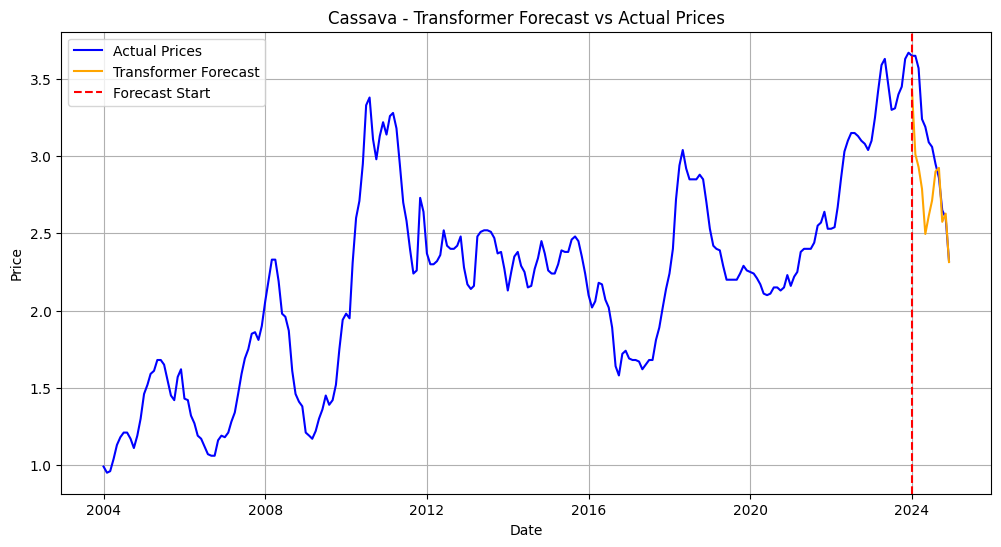

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(tf_forecast.index, tf_forecast, label="Transformer Forecast", color="orange")
plt.axvline(
    x=pd.Timestamp("2024-01-01"), color="red", linestyle="--", label="Forecast Start"
)
plt.title(
    f"{data_file.parent.name.capitalize()} - Transformer Forecast vs Actual Prices"
)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

# Transformer Model And Error Graph

## PLot the Error Analysis graph

<Figure size 1400x800 with 0 Axes>

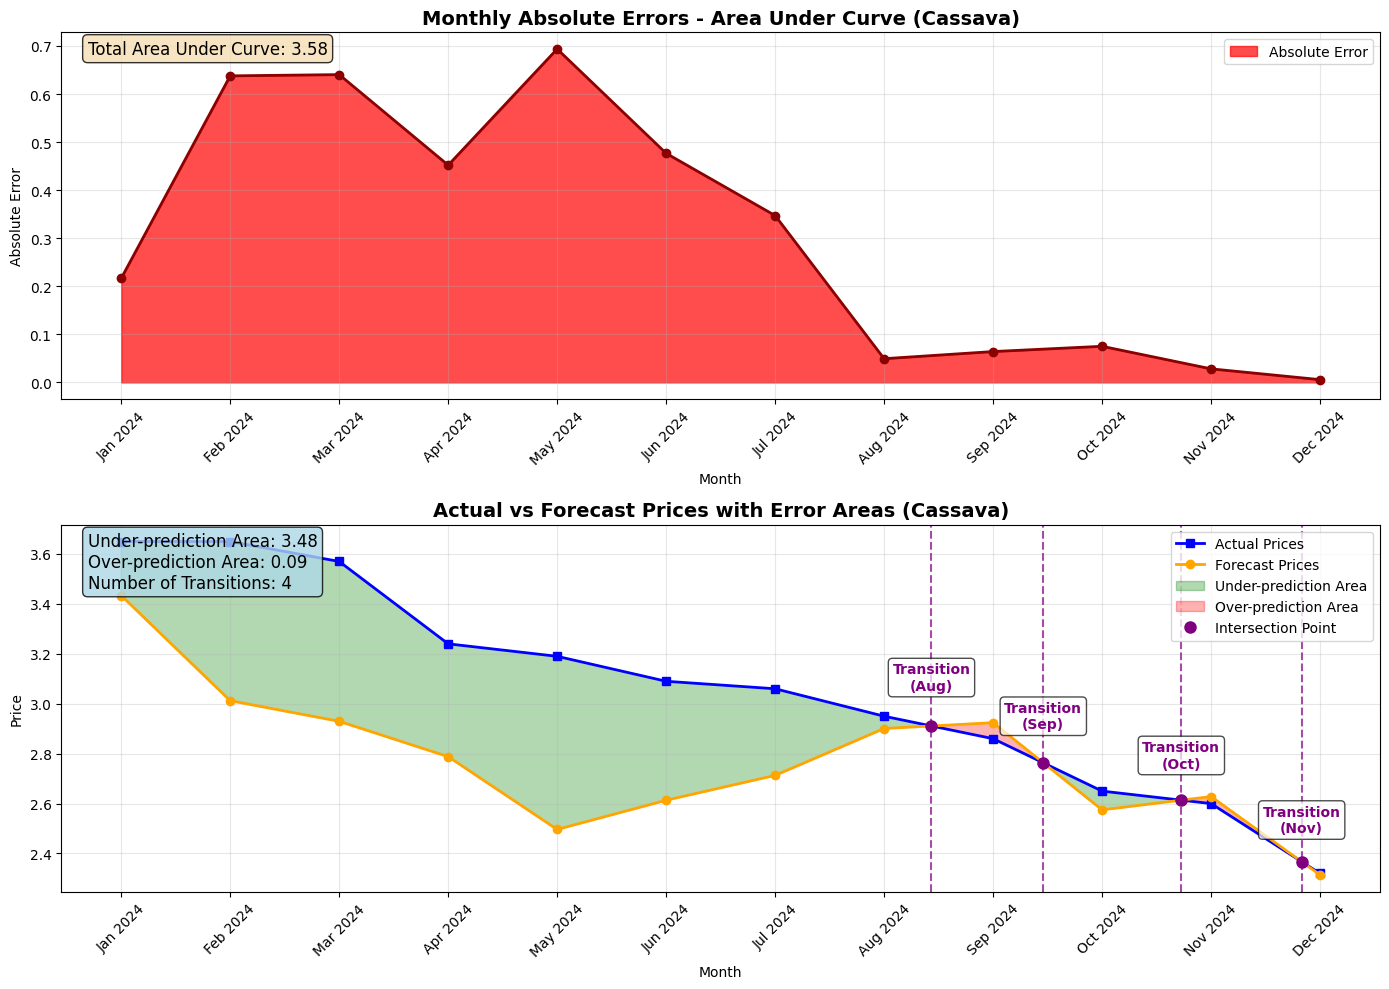

In [48]:
# Create area plot to visualize monthly errors
plt.figure(figsize=(14, 8))

# Calculate error values (in case this cell is run before the error calculation cell)
error = cmp["price"] - cmp["TF_forecast"]
abs_error = abs(error)

# Add the error columns to the cmp DataFrame if they don't exist
if "error" not in cmp.columns:
    cmp["error"] = error
if "abs_error" not in cmp.columns:
    cmp["abs_error"] = abs_error

# Create month labels for better readability
month_labels = [date.strftime("%b %Y") for date in cmp.index]

# Create subplots for different error visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Area plot of absolute errors
ax1.fill_between(
    range(len(cmp)), cmp["abs_error"], alpha=0.7, color="red", label="Absolute Error"
)
ax1.plot(range(len(cmp)), cmp["abs_error"], color="darkred", linewidth=2, marker="o")
ax1.set_title(
    f"Monthly Absolute Errors - Area Under Curve ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Error")
ax1.set_xticks(range(len(cmp)))
ax1.set_xticklabels(month_labels, rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add area calculation text
total_area = np.trapezoid(cmp["abs_error"])
ax1.text(
    0.02,
    0.98,
    f"Total Area Under Curve: {total_area:.2f}",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Comparison of actual vs forecast with error areas
ax2.plot(
    range(len(cmp)),
    cmp["price"],
    label="Actual Prices",
    color="blue",
    linewidth=2,
    marker="s",
)
ax2.plot(
    range(len(cmp)),
    cmp["TF_forecast"],
    label="Forecast Prices",
    color="orange",
    linewidth=2,
    marker="o",
)

# Find intersection points between actual and forecast
intersect_indices = []
for i in range(1, len(cmp)):
    # Check if actual and forecast cross between i-1 and i
    prev_diff = cmp["price"].iloc[i - 1] - cmp["TF_forecast"].iloc[i - 1]
    curr_diff = cmp["price"].iloc[i] - cmp["TF_forecast"].iloc[i]

    if (prev_diff * curr_diff <= 0) and (
        prev_diff != 0 or curr_diff != 0
    ):  # Sign change or one is zero
        # Linear interpolation to find exact intersection point
        if prev_diff == curr_diff:  # They're equal (both 0)
            t = 0  # At point i-1
        else:
            t = abs(prev_diff) / (abs(prev_diff) + abs(curr_diff))

        intersect_x = (i - 1) + t
        intersect_y = cmp["price"].iloc[i - 1] + t * (
            cmp["price"].iloc[i] - cmp["price"].iloc[i - 1]
        )

        intersect_indices.append((intersect_x, intersect_y))

# Fill areas between actual and forecast to show errors
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["TF_forecast"],
    where=(cmp["price"] >= cmp["TF_forecast"]),
    color="green",
    alpha=0.3,
    label="Under-prediction Area",
    interpolate=True,
)
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["TF_forecast"],
    where=(cmp["price"] < cmp["TF_forecast"]),
    color="red",
    alpha=0.3,
    label="Over-prediction Area",
    interpolate=True,
)

# Mark intersection points with vertical lines and markers
for idx, (x, y) in enumerate(intersect_indices):
    ax2.axvline(x, color="purple", linestyle="--", alpha=0.7, linewidth=1.5)
    ax2.plot(
        x,
        y,
        "o",
        color="purple",
        markersize=8,
        label="Intersection Point" if idx == 0 else "",
    )
    ax2.text(
        x,
        y * 1.05,
        f"Transition\n({month_labels[int(x)][:3]})",
        ha="center",
        color="purple",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"),
    )

ax2.set_title(
    f"Actual vs Forecast Prices with Error Areas ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(range(len(cmp)))
ax2.set_xticklabels(month_labels, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# Calculate and display area statistics
under_pred_area = np.trapezoid(np.maximum(cmp["price"] - cmp["TF_forecast"], 0))
over_pred_area = np.trapezoid(np.maximum(cmp["TF_forecast"] - cmp["price"], 0))

# Count number of transitions
num_transitions = len(intersect_indices)

# Create statistics text
stats_text = (
    f"Under-prediction Area: {under_pred_area:.2f}\n"
    f"Over-prediction Area: {over_pred_area:.2f}\n"
    f"Number of Transitions: {num_transitions}"
)

ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
)

plt.tight_layout()
plt.show()

## Analyze The Error of a predicted data

In [49]:
print("\n--- Area Under Curve Analysis ---")
print(f"Total Absolute Error Area: {total_area:.4f}")
print(f"Under-prediction Area: {under_pred_area:.4f}")
print(f"Over-prediction Area: {over_pred_area:.4f}")
print(f"Net Error Area: {under_pred_area - over_pred_area:.4f}")
print(f"Average Monthly Absolute Error: {total_area / len(cmp):.4f}")
print(f"Number of Transition Points: {len(intersect_indices)}")

# Monthly breakdown
print("\n--- Monthly Error Areas ---")
for i, (date, row) in enumerate(cmp.iterrows()):
    month_label = date.strftime("%b %Y")
    error_type = (
        "Under-prediction"
        if row["price"] > row["TF_forecast"]
        else "Over-prediction"
        if row["price"] < row["TF_forecast"]
        else "Exact Match"
    )
    print(f"{month_label}: Abs Error = {row['abs_error']:.4f} ({error_type})")

# Transition analysis
if intersect_indices:
    print("\n--- Transition Points ---")
    for idx, (x, y) in enumerate(intersect_indices):
        transition_month = month_labels[int(x)]
        next_month = month_labels[min(int(x) + 1, len(month_labels) - 1)]
        print(
            f"Transition {idx + 1}: Between {transition_month} and {next_month} at position {x:.2f}"
        )

        # Determine transition type
        i = int(x)
        if i + 1 < len(cmp):
            before_error = cmp["price"].iloc[i] - cmp["TF_forecast"].iloc[i]
            after_error = cmp["price"].iloc[i + 1] - cmp["TF_forecast"].iloc[i + 1]
            direction = (
                "Under to Over"
                if before_error > 0 and after_error < 0
                else "Over to Under"
            )
            print(f"   Direction: {direction} prediction")
else:
    print("\n--- No Transition Points Found ---")
    print(
        "The model consistently either under-predicts or over-predicts throughout the entire period."
    )


--- Area Under Curve Analysis ---
Total Absolute Error Area: 3.5758
Under-prediction Area: 3.4834
Over-prediction Area: 0.0923
Net Error Area: 3.3911
Average Monthly Absolute Error: 0.2980
Number of Transition Points: 4

--- Monthly Error Areas ---
Jan 2024: Abs Error = 0.2165 (Under-prediction)
Feb 2024: Abs Error = 0.6378 (Under-prediction)
Mar 2024: Abs Error = 0.6404 (Under-prediction)
Apr 2024: Abs Error = 0.4520 (Under-prediction)
May 2024: Abs Error = 0.6937 (Under-prediction)
Jun 2024: Abs Error = 0.4766 (Under-prediction)
Jul 2024: Abs Error = 0.3471 (Under-prediction)
Aug 2024: Abs Error = 0.0493 (Under-prediction)
Sep 2024: Abs Error = 0.0642 (Over-prediction)
Oct 2024: Abs Error = 0.0751 (Under-prediction)
Nov 2024: Abs Error = 0.0282 (Over-prediction)
Dec 2024: Abs Error = 0.0057 (Under-prediction)

--- Transition Points ---
Transition 1: Between Aug 2024 and Sep 2024 at position 7.43
   Direction: Under to Over prediction
Transition 2: Between Sep 2024 and Oct 2024 at po

## Save the model Error Analysis to a file 

In [50]:
from util.output_io import save_error_csv, save_summary_csv

save_error_csv(error_df, Transformer_err, data_file.parent.name)


In [51]:
mae_value = mae_tf
mape_value = mape_tf
accuracy = 100 - (mae_tf / cmp["price"].mean() * 100)

summary = {
    "MAE": round(mae_value, 6),
    "MAPE": round(mape_value, 4),
    "accuracy_pct": round(accuracy, 2),
    "total_abs_error_area": round(total_area, 4),
    "under_prediction_area": round(under_pred_area, 4),
    "over_prediction_area": round(over_pred_area, 4),
    "net_error_area": round(under_pred_area - over_pred_area, 4),
    "n_transition_points": len(intersect_indices),
}

save_summary_csv(summary, Transformer_err, data_file.parent.name)


Evaluation metrics saved to: error_record\Transformer\cassava_error_metrics.txt
File size: 1906 bytes
